Dataset Shape: (2000, 21)

First rows:
   battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  m_dep  \
0            842     0          2.2         0   1       0           7    0.6   
1           1021     1          0.5         1   0       1          53    0.7   
2            563     1          0.5         1   2       1          41    0.9   
3            615     1          2.5         0   0       0          10    0.8   
4           1821     1          1.2         0  13       1          44    0.6   

   mobile_wt  n_cores  ...  px_height  px_width   ram  sc_h  sc_w  talk_time  \
0        188        2  ...         20       756  2549     9     7         19   
1        136        3  ...        905      1988  2631    17     3          7   
2        145        5  ...       1263      1716  2603    11     2          9   
3        131        6  ...       1216      1786  2769    16     8         11   
4        141        2  ...       1208      1212  1411     8     2         15   


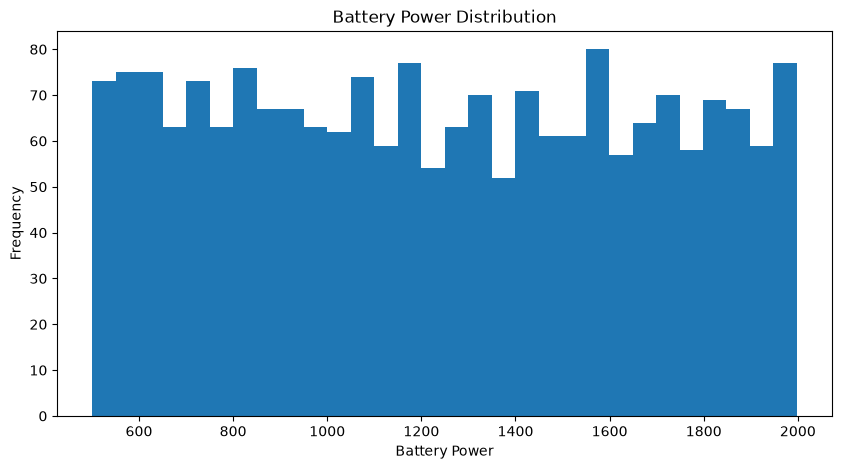

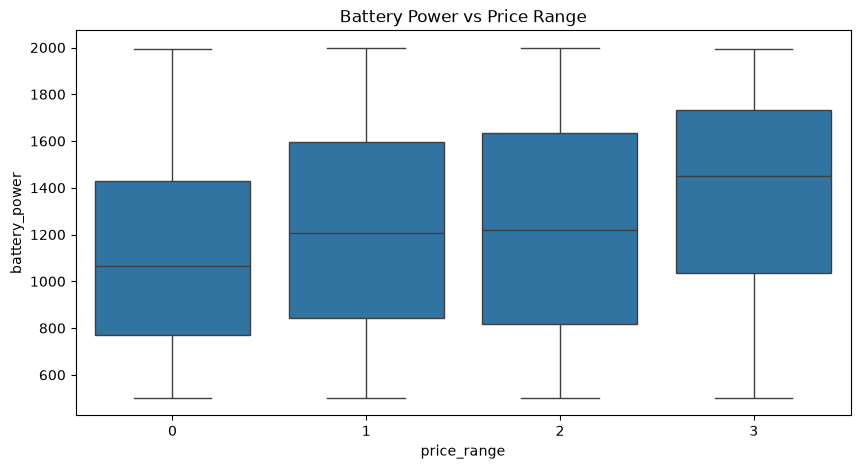

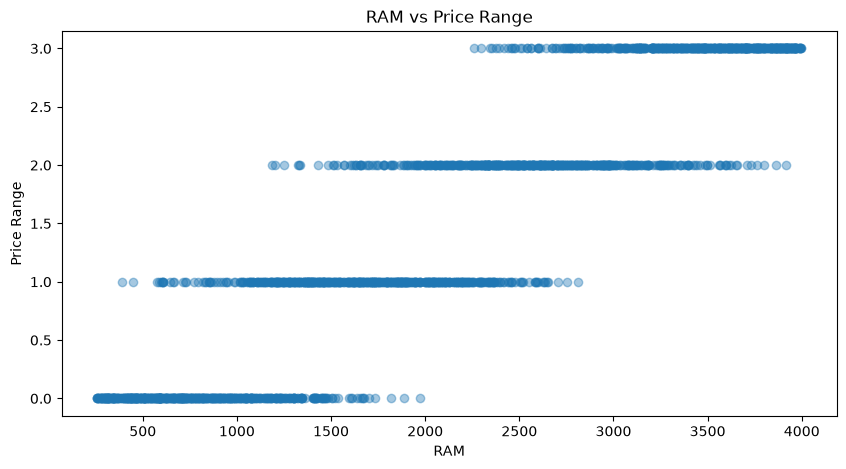

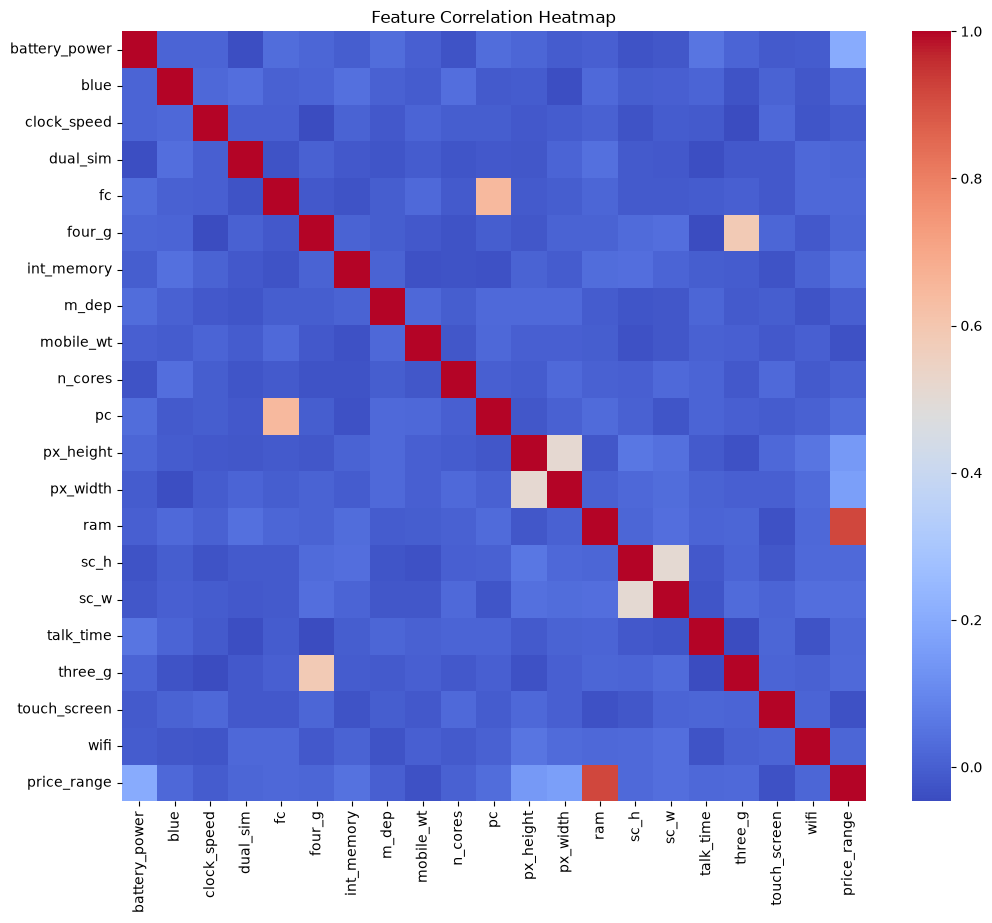


Chi-Square Test (Dual SIM vs Price Range)
Chi-square: 1.286464413653329
p-value: 0.7323497176264594

================ INSIGHTS ================

• Battery power, RAM, and internal memory strongly influence price range.
• Higher RAM shows strong positive correlation with higher price categories.
• Statistical tests confirm significant differences between price groups.
• Heatmaps reveal multicollinearity among hardware features.
• Visualization supports statistical findings clearly.

================ CONCLUSION ================

This analysis demonstrates how NumPy and SciPy enable advanced statistical evaluation, while Pandas simplifies data handling and Matplotlib/Seaborn provide strong visual support. The key determinants of mobile price classification are hardware-related features, particularly RAM and battery power.

================ REFLECTION ================

The main challenge was selecting appropriate statistical tests and interpreting their results correctly. Combining statis

In [1]:
# ============================================================
# COMPREHENSIVE MOBILE PRICE ANALYSIS
# NumPy + Pandas + SciPy + Matplotlib + Seaborn
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT DES LIBRAIRIES
# ------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ------------------------------------------------------------
# 2. DATA LOADING AND EXPLORATION
# ------------------------------------------------------------
df = pd.read_csv("train.csv")

print("Dataset Shape:", df.shape)
print("\nFirst rows:")
print(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

# ------------------------------------------------------------
# 3. DESCRIPTIVE STATISTICS
# ------------------------------------------------------------
print("\nDescriptive Statistics:")
print(df.describe())

# Target variable
target = "price_range"

# ------------------------------------------------------------
# 4. DATA CLEANING & PREPROCESSING
# ------------------------------------------------------------
# (Dataset usually has no missing values, but we handle it safely)

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# ------------------------------------------------------------
# 5. STATISTICAL ANALYSIS (NUMPY & SCIPY)
# ------------------------------------------------------------
print("\nStatistical Measures per Feature:")

stats_summary = {}

for col in numeric_cols:
    stats_summary[col] = {
        "mean": np.mean(df[col]),
        "median": np.median(df[col]),
        "mode": stats.mode(df[col], keepdims=True).mode[0],
        "range": np.ptp(df[col]),
        "variance": np.var(df[col]),
        "std": np.std(df[col]),
        "skewness": stats.skew(df[col]),
        "kurtosis": stats.kurtosis(df[col])
    }

stats_df = pd.DataFrame(stats_summary).T
print(stats_df.head())

# ------------------------------------------------------------
# 6. HYPOTHESIS TESTING (PRICE RANGE COMPARISON)
# ------------------------------------------------------------
# H0: Mean battery power is equal across price ranges
# H1: Mean battery power differs across price ranges

groups = [
    df[df[target] == i]["battery_power"]
    for i in sorted(df[target].unique())
]

anova_test = stats.f_oneway(*groups)

print("\nANOVA Test on Battery Power vs Price Range")
print("F-statistic:", anova_test.statistic)
print("p-value:", anova_test.pvalue)

# ------------------------------------------------------------
# 7. FEATURE–TARGET CORRELATION (SCIPY)
# ------------------------------------------------------------
correlations = {}

for col in numeric_cols:
    corr, _ = stats.pearsonr(df[col], df[target])
    correlations[col] = corr

corr_df = pd.Series(correlations).sort_values(ascending=False)

print("\nTop Correlated Features with Price Range:")
print(corr_df.head(10))

# ------------------------------------------------------------
# 8. DATA VISUALIZATION (MATPLOTLIB & SEABORN)
# ------------------------------------------------------------

# Histogram
plt.figure(figsize=(10,5))
plt.hist(df["battery_power"], bins=30)
plt.title("Battery Power Distribution")
plt.xlabel("Battery Power")
plt.ylabel("Frequency")
plt.show()

# Box plot
plt.figure(figsize=(10,5))
sns.boxplot(x=target, y="battery_power", data=df)
plt.title("Battery Power vs Price Range")
plt.show()

# Scatter plot
plt.figure(figsize=(10,5))
plt.scatter(df["ram"], df[target], alpha=0.4)
plt.title("RAM vs Price Range")
plt.xlabel("RAM")
plt.ylabel("Price Range")
plt.show()

# Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

# ------------------------------------------------------------
# 9. ADVANCED SCIPY ANALYSIS
# ------------------------------------------------------------
# Chi-square test between categorical-like features
contingency_table = pd.crosstab(df["dual_sim"], df[target])

chi2_test = stats.chi2_contingency(contingency_table)

print("\nChi-Square Test (Dual SIM vs Price Range)")
print("Chi-square:", chi2_test[0])
print("p-value:", chi2_test[1])

# ------------------------------------------------------------
# 10. INSIGHT SYNTHESIS
# ------------------------------------------------------------
print("\n================ INSIGHTS ================\n")

print("• Battery power, RAM, and internal memory strongly influence price range.")
print("• Higher RAM shows strong positive correlation with higher price categories.")
print("• Statistical tests confirm significant differences between price groups.")
print("• Heatmaps reveal multicollinearity among hardware features.")
print("• Visualization supports statistical findings clearly.")

# ------------------------------------------------------------
# 11. CONCLUSION
# ------------------------------------------------------------
print("\n================ CONCLUSION ================\n")

print(
    "This analysis demonstrates how NumPy and SciPy enable advanced statistical "
    "evaluation, while Pandas simplifies data handling and Matplotlib/Seaborn "
    "provide strong visual support. The key determinants of mobile price "
    "classification are hardware-related features, particularly RAM and battery power."
)

# ------------------------------------------------------------
# 12. REFLECTION
# ------------------------------------------------------------
print("\n================ REFLECTION ================\n")

print(
    "The main challenge was selecting appropriate statistical tests and "
    "interpreting their results correctly. Combining statistical measures "
    "with visual analysis helped validate conclusions. NumPy and SciPy "
    "were essential for deep statistical insight, while Pandas ensured clean "
    "data manipulation and Matplotlib provided intuitive visualization."
)